# TM10007 Machine Learning Group 10 Liver 

In [12]:
# Run this to use from colab environment
!pip install -q --upgrade git+https://github.com/jveenland/tm10007_ml.git

## Importing packages 


In [13]:
# General packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets as ds
import seaborn as sns

# Classifiers
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn import svm


# Statistics
from sklearn import model_selection
from sklearn import metrics
from sklearn import svm
from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import KFold, train_test_split, GridSearchCV, learning_curve, StratifiedKFold, cross_val_score
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif, RFE, RFECV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, auc, mean_squared_error
from scipy.stats import zscore, shapiro
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA


## Data loading 

Below are functions to load the dataset of your choice. After that, it is all up to you to create and evaluate a classification method. Beware, there may be missing values in these datasets. Good luck!

In [14]:
from worcliver.load_data import load_data

# Load the data
data = load_data()

# Replace the labels with binary labels
data_binary = data.copy()
data_binary["label"] = data_binary["label"].map({"malignant": 1, "benign": 0})

# Print number of samples and columns
print(f"The number of samples: {len(data_binary.index)}")
print(f"The number of columns: {len(data_binary.columns)}")
print(f"The number of malignant samples: {sum(data_binary['label']==1)}")
print(f"The number of benign samples: {sum(data_binary['label']==0)}")

The number of samples: 186
The number of columns: 494
The number of malignant samples: 94
The number of benign samples: 92


## Data preprocessing

In [15]:
# Checking for duplicate samples
duplicate_samples = data_binary[data_binary.duplicated()]
if len(duplicate_samples) > 0:
    print(f"Number of duplicate rows: {len(duplicate_samples)}")
else:
    print("No duplicate sample found.")   
# Remove duplicate samples
data_cleaned = data_binary.drop_duplicates()

# Checking for duplicate features
duplicate_features = data_cleaned.columns[data_cleaned.columns.duplicated()]
if len(duplicate_features) > 0:
    print(f"Number of duplicate features: {len(duplicate_features)}")
    print("Duplicate feature names:")
    print(list(duplicate_features))
    # Remove duplicate features
    data_cleaned = data_cleaned.loc[:, ~data_cleaned.columns.duplicated()]   
else:
    print("No duplicate features found.")

# Checking for missing data
# Check for infinite values
print(f"Amount of infinite data: {data_cleaned.map(np.isinf).sum().sum()}")
# Check for missing values
print(f"Amount of missing data: {data_cleaned.isna().sum().sum()}")


No duplicate sample found.
No duplicate features found.
Amount of infinite data: 0
Amount of missing data: 0


## Data splitting


In [16]:
# Split the dataset in features and labels
X = data_cleaned.drop(columns=["label"])
y = data_cleaned["label"]

# Split the dataset in train and test part
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print the number of samples in the train and test set
print(f"The number of samples in the train set: {len(X_train.index)}")
print(f"The number of samples in the test set: {len(X_test.index)}")


The number of samples in the train set: 148
The number of samples in the test set: 38


## Scaling 
First check the distribution of the data, we check for normal and not normal distribution and we check the data on outliers

In [17]:
# Checking the distribution of the columns of the dataset and filling in missing values
alpha = 0.05
nd_columns_train = 0
nnd_columns_train = 0

for column in X_train:
    if X_train[column].min() != X_train[column].max():
        # Perform Shapiro-Wilk test for normality
        stat, p = shapiro(X_train[column].dropna())
        # Interpret the result
        if p > alpha:
            nd_columns_train += 1
            if X_train[column].isna().sum() > 0:
                # Fill missing values with the mean of the column
                X_train[column].fillna(X_train[column].mean(), inplace=True)
        else:
            nnd_columns_train += 1
            if X_train[column].isna().sum() > 0:
                # Fill missing values with the median of the column
                X_train[column].fillna(X_train[column].median(), inplace=True)
print(f"Number of normal distributed columns in the train set: {nd_columns_train}")
print(f"Number of non-normal distributed columns in the train set: {nnd_columns_train}")
    

Number of normal distributed columns in the train set: 53
Number of non-normal distributed columns in the train set: 423


In [18]:
# Calculating presence and number of outliers
columns_many_outliers_count = 0

for column in X_train:
    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)
    IQR = Q3 - Q1

    outliers = X_train[(X_train[column] < (Q1 - 1.5 * IQR)) | (X_train[column] > (Q3 + 1.5 * IQR))]
    outliers_count = outliers.shape[0]

    if outliers_count > 0.05 * X_train.shape[0]:
        columns_many_outliers_count += 1

perc_columns_many_outliers = (columns_many_outliers_count / len(X_train.columns)) * 100
print(f"Number of columns with many outliers: {columns_many_outliers_count}/{len(X_train.columns)} = {perc_columns_many_outliers:.2f}%")

Number of columns with many outliers: 166/493 = 33.67%


### Scaling the data

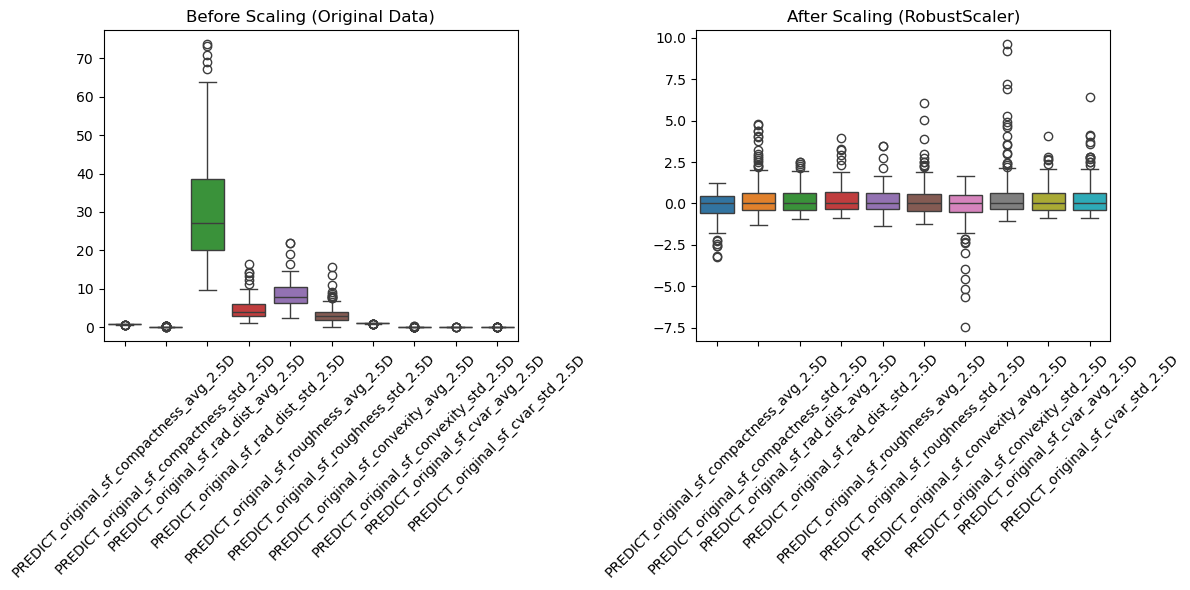

In [19]:
scaler = RobustScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled) 

features_to_plot = X_train.columns[:10] 
# Create a figure with two subplots
plt.figure(figsize=(12, 6))

# Plot original (unscaled) data
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train[features_to_plot])
plt.title("Before Scaling (Original Data)")
plt.xticks(rotation=45)

# Plot scaled data
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled[features_to_plot])
plt.title("After Scaling (RobustScaler)")
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()


### Feature selection

In [20]:
# Remove constant features
selector = VarianceThreshold(0)  # Remove near-constant features
X_reduced = selector.fit_transform(X_train_scaled)

print(f"Reduced from {X_train_scaled.shape[1]} to {X_reduced.shape[1]} features")


Reduced from 493 to 476 features


In [33]:
# KBest feature selection
k = 476  # Number of features to select
method1 = mutual_info_classif # SelectKBest method
method2 = f_classif # SelectKBest method
selector = SelectKBest(method2, k=k)
X_selected = selector.fit_transform(X_reduced, y_train)

# Classifiers to test
models = {
    "kNN": KNeighborsClassifier(),
    "SVM": SVC(kernel="rbf")
}

# Set up Stratified K-Folds Cross Validation to ensure each fold has a similar class distribution
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold cross-validation

# Cross-validation for each model
for model_name, model in models.items():
    print(f"\nEvaluating {model_name} using Cross-Validation...")

    # Use cross-validation to evaluate the model
    cv_scores = cross_val_score(model, X_selected, y_train, cv=cv, scoring='accuracy')

    # Print out the results
    print(f"Cross-Validation Scores: {cv_scores}")
    print(f"Mean Accuracy: {np.mean(cv_scores):.4f}")
    print(f"Standard Deviation of Accuracy: {np.std(cv_scores):.4f}")



Evaluating kNN using Cross-Validation...
Cross-Validation Scores: [0.53333333 0.56666667 0.53333333 0.55172414 0.72413793]
Mean Accuracy: 0.5818
Standard Deviation of Accuracy: 0.0722

Evaluating SVM using Cross-Validation...
Cross-Validation Scores: [0.5        0.5        0.5        0.48275862 0.51724138]
Mean Accuracy: 0.5000
Standard Deviation of Accuracy: 0.0109


In [22]:
# RFE en RFECV feature selection kunnen volgens mij niet goed bij KNN en SVM met een RBF kernel (die we nodig hebben omdat de data niet polynomial
# of linear te scheiden is)

# Correlation alone
corr_matrix = X_train_scaled.corr()
# Remove features with correlation higher than a threshold
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.9)]
df = X_train_scaled.drop(to_drop, axis=1)
print(f"Reduced from {X_train_scaled.shape[1]} to {df.shape[1]} features")

#try correlation feature selection
X_selected2 = pd.DataFrame(X_selected)
corr_matrix = X_selected2.corr()
# Remove features with correlation higher than a threshold
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.9)]
df = X_selected2.drop(to_drop, axis=1)
print(f"Reduced from {X_selected2.shape[1]} to {df.shape[1]} features")

Reduced from 493 to 232 features
Reduced from 50 to 35 features


In [23]:
# PCA alone
pca = PCA(n_components=0.95)  # Retain 95% of variance
X_train_pca = pca.fit_transform(X_train_scaled)

print(f"Reduced from {X_train_scaled.shape[1]} to {X_train_pca.shape[1]} features")

# KBest + PCA
pca = PCA(n_components=0.95)  # Retain 95% of variance
X_train_pca = pca.fit_transform(X_selected)

print(f"Reduced from {X_selected.shape[1]} to {X_train_pca.shape[1]} features")

Reduced from 493 to 1 features
Reduced from 50 to 9 features


SVM
PCA
1
6
11
16
21
26
31
36
41
46
51
56
61
66
71
76
81
86
91
96
101
106
111
116
121
126
131
136
141
146
KBest (f_classif)
1
6
11
16
21
26
31
36
41
46
51
56
61
66
71
76
81
86
91
96
101
106
111
116
121
126
131
136
141
146
KBest (mutual_info_classif)
1
6
11
16
21
26
31
36
41
46
51
56
61
66
71
76
81
86
91
96
101
106
111
116
121
126
131
136
141
146
KNN
PCA
1
6
11
16
21
26
31
36
41
46
51
56
61
66
71
76
81
86
91
96
101
106
111
116
121
126
131
136
141
146
KBest (f_classif)
1
6
11
16
21
26
31
36
41
46
51
56
61
66
71
76
81
86
91
96
101
106
111
116
121
126
131
136
141
146
KBest (mutual_info_classif)
1
6
11
16
21
26
31
36
41
46
51
56
61
66
71
76
81
86
91
96
101
106
111
116
121
126
131
136
141
146


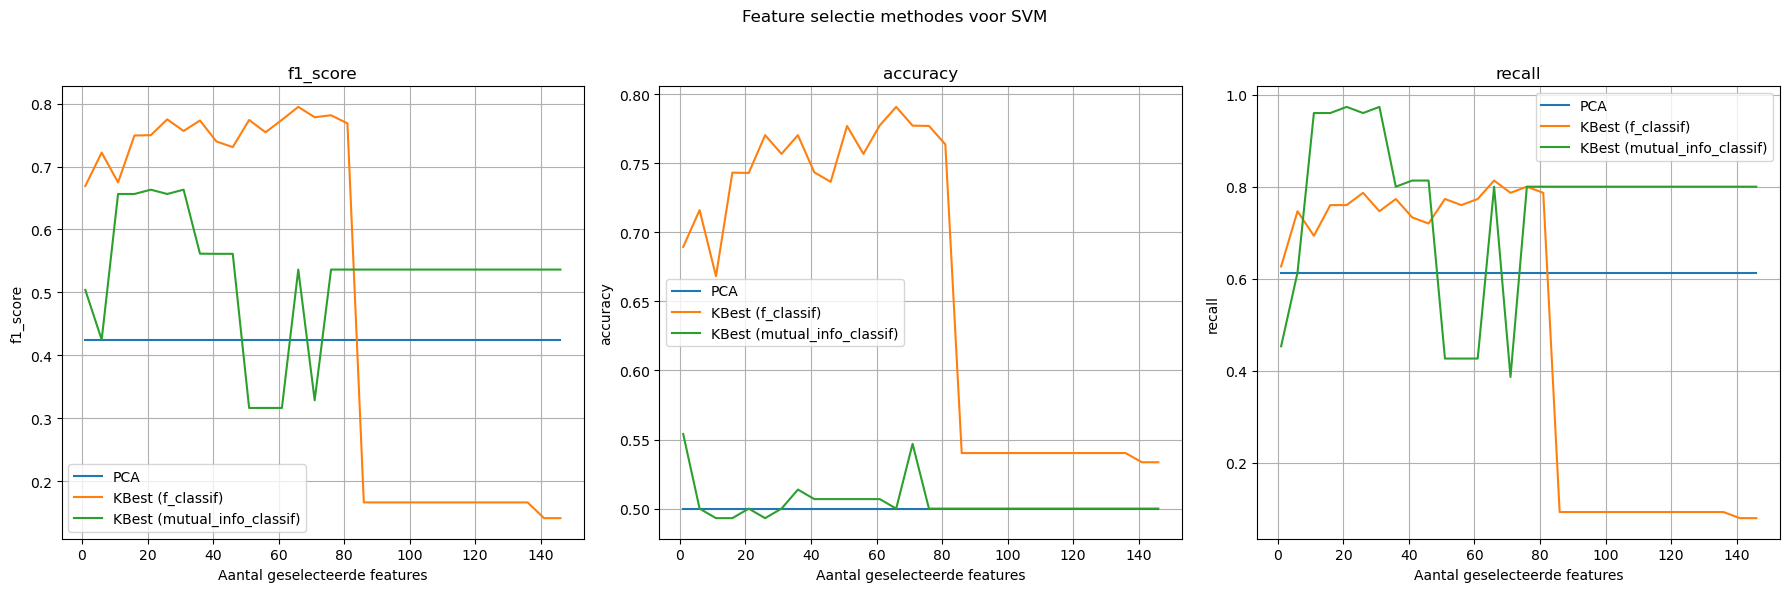

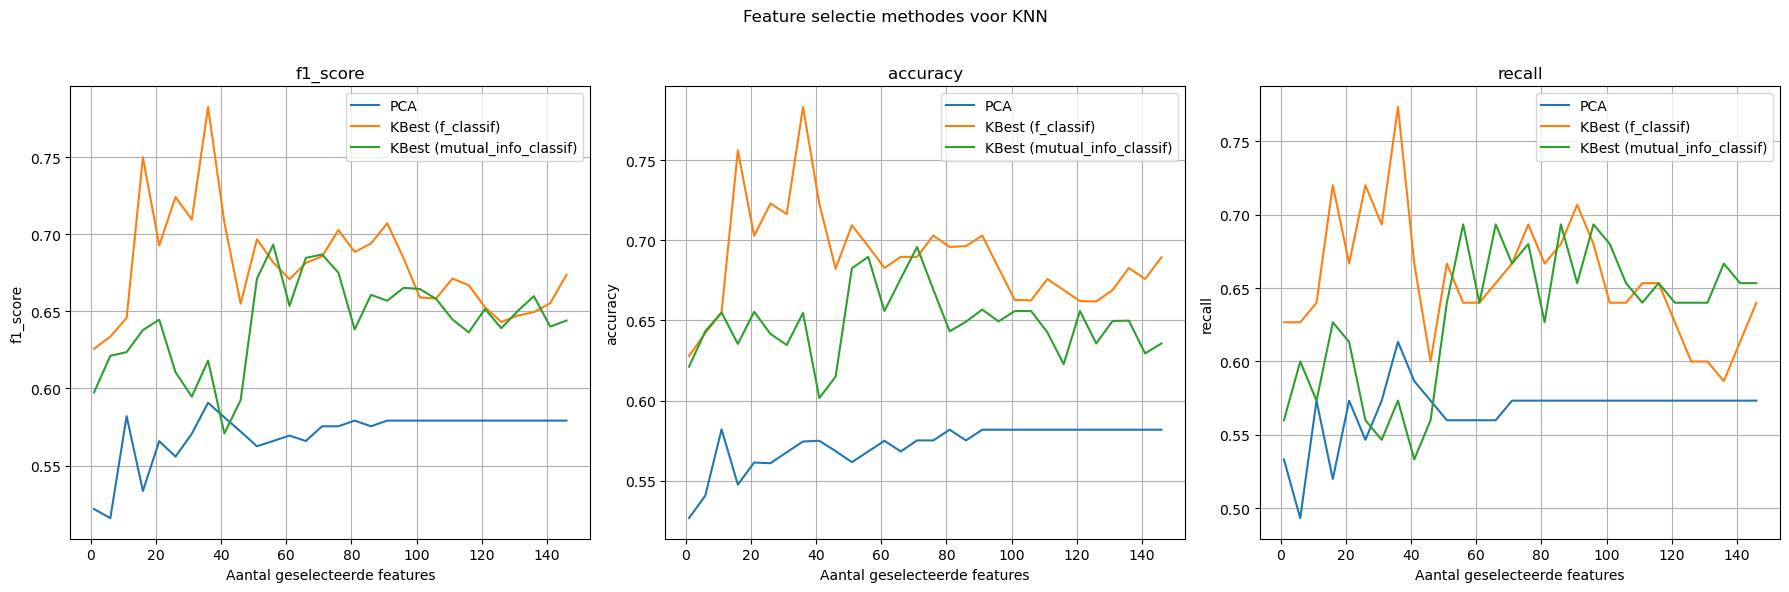

In [31]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import make_scorer, f1_score, recall_score

# Classificatie algoritmes
classifiers = {
    "SVM": SVC(kernel="rbf"),
    "KNN": KNeighborsClassifier()
}

# Feature selectie methodes
feature_selection_methods = {
    "PCA": PCA(),
    "KBest (f_classif)": SelectKBest(score_func=f_classif),
    "KBest (mutual_info_classif)": SelectKBest(score_func=mutual_info_classif),
    #"Greedy Selection": SequentialFeatureSelector(estimator=SVC(kernel='rbf'), n_features_to_select="auto", scoring='f1', direction='forward')
}

# Metrics instellen
scoring_metrics = {
    "f1_score": make_scorer(f1_score),
    "accuracy": make_scorer(accuracy_score),
    "recall": make_scorer(recall_score)
}

# Gebruik StratifiedKFold voor betrouwbaardere cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Opslag voor scores
scores = {clf_name: {method: {metric: [] for metric in scoring_metrics} for method in feature_selection_methods} for clf_name in classifiers}

# Aantal features om te testen
n_features_range = range(1, min(X_reduced.shape), 5)

# Test verschillende feature selectie methodes
for classifier_name, classifier in classifiers.items():
    print(classifier_name)
    for method_name, selector in feature_selection_methods.items():
        print(method_name)
        for n_features in n_features_range:
            print(n_features)
            # Pas de feature selectie methode toe
            if method_name == "PCA":
                selector.n_components = n_features  # Voor PCA
            else:
                selector.k = n_features  # Voor KBest selectie
                
            # Selecteer de features
            X_selected = selector.fit_transform(X_reduced, y_train)
            
            # Bereken de scores voor elke metric
            for metric_name, scorer in scoring_metrics.items():
                score = np.mean(cross_val_score(classifier, X_selected, y_train, cv=cv, scoring=scorer))
                scores[classifier_name][method_name][metric_name].append(score)

# Plot de resultaten per classifier met subplots voor f1-score, accuracy, recall
for classifier_name, classifier in classifiers.items():
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"Feature selectie methodes voor {classifier_name}")
    
    # Voor elke metric (f1-score, accuracy, recall)
    for i, (metric_name, ax) in enumerate(zip(scoring_metrics.keys(), axes)):
        ax.set_title(metric_name)
        for method_name, method_scores in scores[classifier_name].items():
            ax.plot(n_features_range, method_scores[metric_name], label=method_name)
        
        ax.set_xlabel("Aantal geselecteerde features")
        ax.set_ylabel(metric_name)
        ax.grid(True)
        ax.legend()
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Zorgt ervoor dat de titel boven de subplots komt
    plt.show()

In [32]:
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# Feature selection methoden
feature_selection_methods = {
    "SelectKBest_f_classif": SelectKBest(score_func=f_classif),
    "SelectKBest_mutual_info": SelectKBest(score_func=mutual_info_classif),
}

# Classificatie algoritmes
classifiers = {
    "SVM": SVC(kernel = "rbf"),
    "KNN": KNeighborsClassifier()
}
best_combinations = {}

for classifier_name, classifier in classifiers.items():
    best_score = 0
    best_method = None
    best_k = None
    
    for feature_selection_name, feature_selector in feature_selection_methods.items():
        print(f'evaluation {classifier_name} with {feature_selection_name}')
        for k in range(1, 51, 1):  # Optimaliseer aantal features
            print(f'k = {k}')
            if isinstance(feature_selector, SelectKBest):
                feature_selector.set_params(k=k)
            elif isinstance(feature_selector, PCA):
                feature_selector.set_params(n_components=k / X_train.shape[1])
            
            pipeline = Pipeline([
                ('feature_selection', feature_selector),
                ('classifier', classifier)
            ])
            
            cv_scores = cross_val_score(pipeline, X_reduced, y_train, cv=5, scoring='accuracy')
            mean_accuracy = np.mean(cv_scores)
            
            if mean_accuracy > best_score:
                best_score = mean_accuracy
                best_method = feature_selection_name
                best_k = k
    
    best_combinations[classifier_name] = (best_method, best_k, best_score)

for clf, (method, k, score) in best_combinations.items():
    print(f"Beste combinatie voor {clf}: Feature Selection = {method}, k = {k}, Score = {score:.4f}")

evaluation SVM with SelectKBest_f_classif
k = 1
k = 2
k = 3
k = 4
k = 5
k = 6
k = 7


c:\Users\liann\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [412 425 438] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\liann\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\liann\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [84 90] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\liann\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\liann\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [412 425 438] are constant.
  warnings.warn("Features %s are constant." % constant_f

k = 8
k = 9
k = 10
k = 11
k = 12
k = 13
k = 14
k = 15


c:\Users\liann\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [412 425 438] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\liann\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\liann\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [84 90] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\liann\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\liann\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [412 425 438] are constant.
  warnings.warn("Features %s are constant." % constant_f

k = 16
k = 17
k = 18
k = 19
k = 20
k = 21
k = 22


...

k = 41
k = 42
k = 43
k = 44
k = 45


c:\Users\liann\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [412 425 438] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\liann\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\liann\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [84 90] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\liann\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\liann\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [412 425 438] are constant.
  warnings.warn("Features %s are constant." % constant_f

k = 46
k = 47
k = 48
k = 49
k = 50


c:\Users\liann\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [412 425 438] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\liann\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\liann\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [84 90] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\liann\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\liann\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [412 425 438] are constant.
  warnings.warn("Features %s are constant." % constant_f

evaluation KNN with SelectKBest_mutual_info
k = 1
k = 2
k = 3
k = 4
k = 5
k = 6
k = 7
k = 8
k = 9
k = 10
k = 11
k = 12
k = 13
k = 14
k = 15
k = 16
k = 17
k = 18
k = 19
k = 20
k = 21
k = 22
k = 23
k = 24
k = 25
k = 26
k = 27
k = 28
k = 29
k = 30
k = 31
k = 32
k = 33
k = 34
k = 35
k = 36
k = 37
k = 38
k = 39
k = 40
k = 41
k = 42
k = 43
k = 44
k = 45
k = 46
k = 47
k = 48
k = 49
k = 50
Beste combinatie voor SVM: Feature Selection = SelectKBest_f_classif, k = 22, Score = 0.7361
Beste combinatie voor KNN: Feature Selection = SelectKBest_f_classif, k = 44, Score = 0.7034
